Original shape: (854, 854, 3)
convolution shape  (854, 854, 1)
relu shape (854, 854, 1)
Pooled max shape:  (427, 427, 1)
Unpooled max shape  (854, 854, 1)
backwards pass relu shape (854, 854, 1)
unconvolved backwards shape (854, 854, 3)


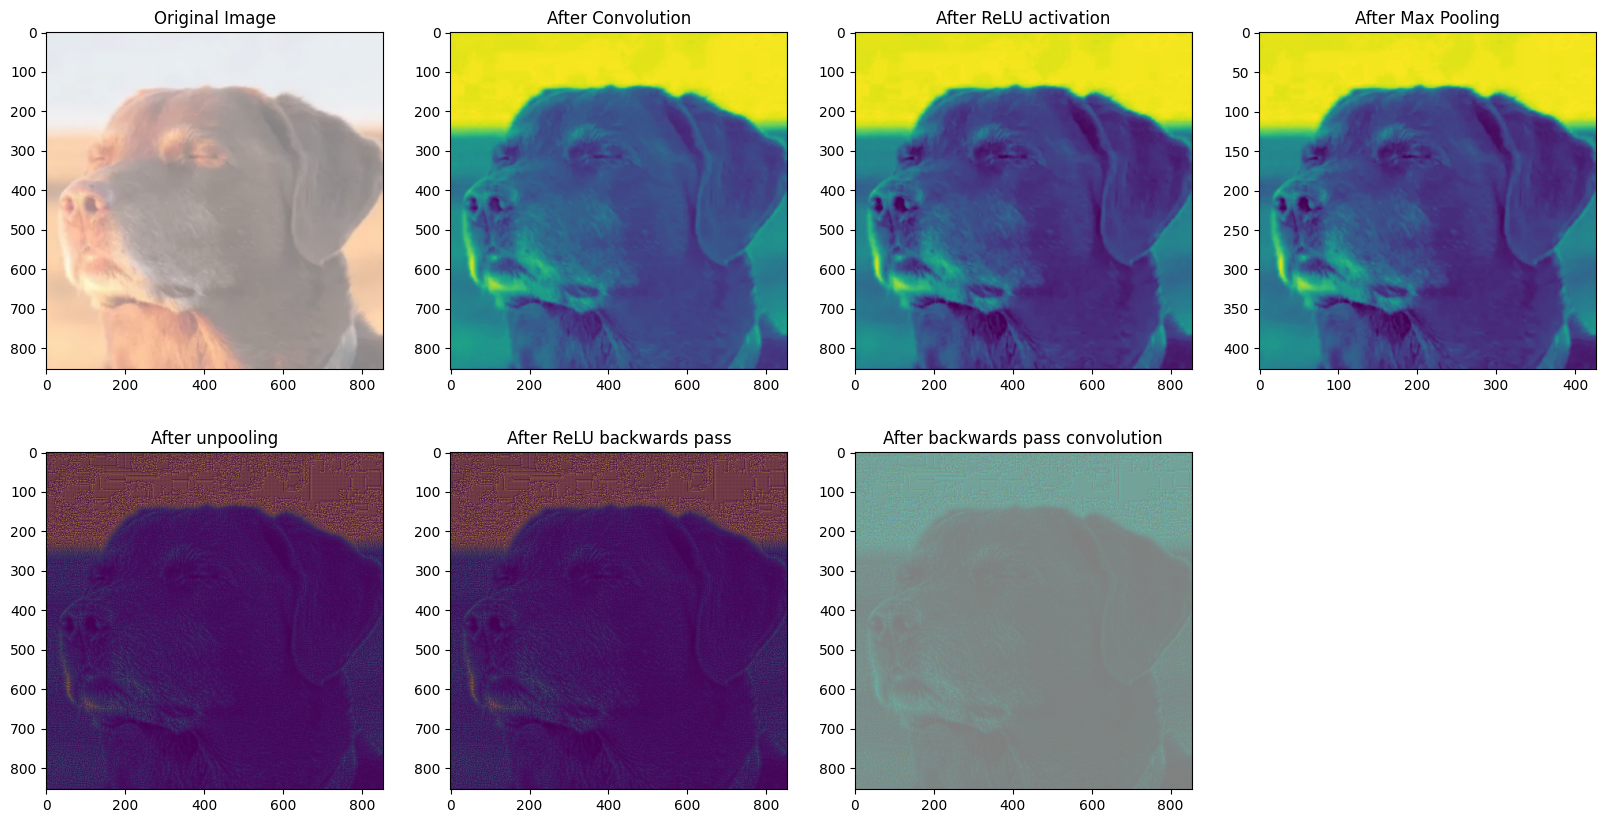

In [ ]:
import cupy as cp
import numpy as np
from CNN.models.CNN_model_cupy import *

import matplotlib.image as mpimg
import matplotlib.pyplot as plt

def normalize_signed(x):
    m = np.max(np.abs(x))
    return (x / (m + 1e-8)) * 0.5 + 0.5  # map [-1,1] → [0,1]


img = mpimg.imread("CNN/JupyterNotebookVisuals/dog.png")
print("Original shape:", img.shape)    #(854 rows, 854 columns, 3 channels rgb)
img = img[cp.newaxis, ...]
img = cp.asarray(img, dtype = cp.float32)
conv1 = Conv_Layer(input_shape = (28, 28, 3), num_filters = 1,
                    filter_size = (3, 3), strides = (1, 1), padding = "same")
activation1 = ReLU()
pool2 = Pooling(filter_size = (2, 2), strides = (2, 2), padding = "valid", pooling_type = "max")

convoluted = conv1.forward(inputs = img, training = False)
activated = activation1.forward(inputs = conv1.output, training= False)
pooled_max = pool2.forward(inputs = activation1.output, training= False)

unpooled_max = pool2.backward(dvalues = pool2.output)
activation1.backward(dvalues = pool2.dinputs)
unactivated = activation1.dinputs
unconvolved = conv1.backward(dvalues = activation1.dinputs)

img           = np.squeeze(cp.asnumpy(img), axis=0)
convoluted    = np.squeeze(cp.asnumpy(convoluted), axis=0)
activated     = np.squeeze(cp.asnumpy(activated), axis=0)
pooled_max    = np.squeeze(cp.asnumpy(pooled_max), axis=0)

unpooled_max  = np.squeeze(cp.asnumpy(unpooled_max), axis=0)
unactivated   = np.squeeze(cp.asnumpy(unactivated), axis=0)
unconvolved   = np.squeeze(cp.asnumpy(unconvolved), axis=0)


print("convolution shape ", convoluted.shape)
print("relu shape" , activated.shape)
print("Pooled max shape: ", pooled_max.shape)
print("Unpooled max shape ", unpooled_max.shape)
print("backwards pass relu shape", unactivated.shape)
print("unconvolved backwards shape", unconvolved.shape)

arrays = {
    "img": img,
    "convoluted": convoluted,
    "activated": activated,
    "pooled_max": pooled_max,
    "unpooled_max": unpooled_max,
    "unactivated": unactivated,
    "unconvolved": unconvolved
}

# output dictionary
normalized = {}

for name, arr in arrays.items():
    arr_np = cp.asnumpy(arr)          # CuPy → NumPy
    if arr_np.ndim >= 4 and arr_np.shape[0] == 1:
        arr_np = np.squeeze(arr_np, 0)    # remove batch dimension
    normalized[name] = normalize_signed(arr_np)

plt.figure(figsize=(20, 10))

plt.subplot(2, 4, 1)
plt.imshow(normalized["img"])
plt.title("Original Image")
plt.axis("on")

plt.subplot(2, 4, 2)
plt.imshow(normalized["convoluted"])
plt.title("After Convolution")
plt.axis("on")

plt.subplot(2, 4, 3)
plt.imshow(normalized["activated"])
plt.title("After ReLU activation")
plt.axis("on")

plt.subplot(2, 4, 4)
plt.imshow(normalized["pooled_max"])
plt.title("After Max Pooling")
plt.axis("on")

plt.subplot(2, 4, 5)
plt.imshow(normalized["unpooled_max"])
plt.title("After unpooling")
plt.axis("on")

plt.subplot(2, 4, 6)
plt.imshow(normalized["unactivated"])
plt.title("After ReLU backwards pass")
plt.axis("on")

plt.subplot(2, 4, 7)
plt.imshow(normalized["unconvolved"])
plt.title("After backwards pass convolution")
plt.axis("on")

plt.show()

Original shape: (256, 256, 3)
convolution shape  (256, 256, 1)
relu shape (256, 256, 1)
Pooled max shape:  (128, 128, 1)
Unpooled max shape  (256, 256, 1)
backwards pass relu shape (256, 256, 1)
unconvolved backwards shape (256, 256, 3)


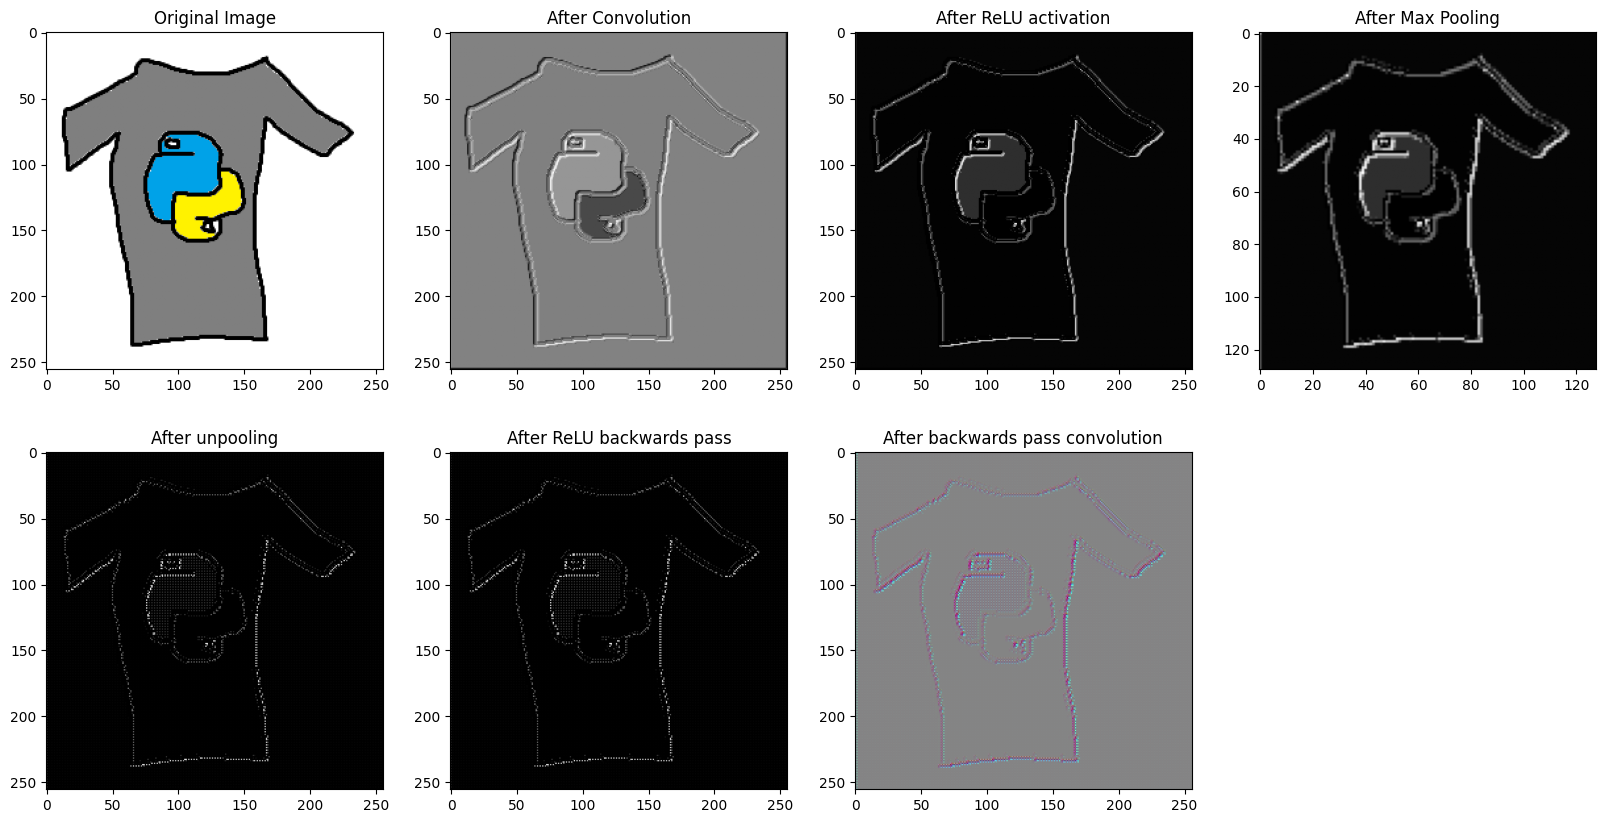

In [ ]:
import cupy as cp
import numpy as np
from CNN.models.CNN_model_cupy import *

import matplotlib.image as mpimg
import matplotlib.pyplot as plt

def normalize_signed(x):
    m = np.max(np.abs(x))
    return (x / (m + 1e-8)) * 0.5 + 0.5  # map [-1,1] → [0,1]

def normalize_unsigned(x):
    x = x - x.min()     # bring minimum to 0
    return x / (x.max() + 1e-8)

def normalize_clip(x):
    x = np.clip(x, -1, 1)
    return (x + 1) / 2



img = mpimg.imread("CodeTest/tshirt.png")
print("Original shape:", img.shape)    #(854 rows, 854 columns, 3 channels rgb)
img = img[cp.newaxis, ...]
img = cp.asarray(img, dtype = cp.float32)
conv1 = Conv_Layer(input_shape = (28, 28, 3), num_filters = 1,
                    filter_size = (3, 3), strides = (1, 1), padding = "same")
activation1 = ReLU()
pool2 = Pooling(filter_size = (2, 2), strides = (2, 2), padding = "valid", pooling_type = "max")

convoluted = conv1.forward(inputs = img, training = False)
activated = activation1.forward(inputs = conv1.output, training= False)
pooled_max = pool2.forward(inputs = activation1.output, training= False)

unpooled_max = pool2.backward(dvalues = pool2.output)
activation1.backward(dvalues = pool2.dinputs)
unactivated = activation1.dinputs
unconvolved = conv1.backward(dvalues = activation1.dinputs)

img           = np.squeeze(cp.asnumpy(img), axis=0)
convoluted    = np.squeeze(cp.asnumpy(convoluted), axis=0)
activated     = np.squeeze(cp.asnumpy(activated), axis=0)
pooled_max    = np.squeeze(cp.asnumpy(pooled_max), axis=0)

unpooled_max  = np.squeeze(cp.asnumpy(unpooled_max), axis=0)
unactivated   = np.squeeze(cp.asnumpy(unactivated), axis=0)
unconvolved   = np.squeeze(cp.asnumpy(unconvolved), axis=0)


print("convolution shape ", convoluted.shape)
print("relu shape" , activated.shape)
print("Pooled max shape: ", pooled_max.shape)
print("Unpooled max shape ", unpooled_max.shape)
print("backwards pass relu shape", unactivated.shape)
print("unconvolved backwards shape", unconvolved.shape)

arrays = {
    "img": img,
    "convoluted": convoluted,
    "activated": activated,
    "pooled_max": pooled_max,
    "unpooled_max": unpooled_max,
    "unactivated": unactivated,
    "unconvolved": unconvolved
}

# output dictionary
normalized = {}

for name, arr in arrays.items():
    arr_np = cp.asnumpy(arr)          # CuPy → NumPy
    if arr_np.ndim >= 4 and arr_np.shape[0] == 1:
        arr_np = np.squeeze(arr_np, 0)    # remove batch dimension
    normalized[name] = normalize_unsigned(arr_np)

plt.figure(figsize=(20, 10))

plt.subplot(2, 4, 1)
plt.imshow(normalized["img"], cmap = "gray", vmin = 0, vmax = 1)
plt.title("Original Image")
plt.axis("on")

plt.subplot(2, 4, 2)
plt.imshow(normalized["convoluted"], cmap = "gray", vmin = 0, vmax = 1)
plt.title("After Convolution")
plt.axis("on")

plt.subplot(2, 4, 3)
plt.imshow(normalized["activated"], cmap = "gray", vmin = 0, vmax = 1)
plt.title("After ReLU activation")
plt.axis("on")

plt.subplot(2, 4, 4)
plt.imshow(normalized["pooled_max"], cmap = "gray", vmin = 0, vmax = 1)
plt.title("After Max Pooling")
plt.axis("on")

plt.subplot(2, 4, 5)
plt.imshow(normalized["unpooled_max"], cmap = "gray", vmin = 0, vmax = 1)
plt.title("After unpooling")
plt.axis("on")

plt.subplot(2, 4, 6)
plt.imshow(normalized["unactivated"], cmap = "gray", vmin = 0, vmax = 1)
plt.title("After ReLU backwards pass")
plt.axis("on")

plt.subplot(2, 4, 7)
plt.imshow(normalized["unconvolved"], cmap = "gray", vmin = 0, vmax = 1)
plt.title("After backwards pass convolution")
plt.axis("on")

plt.show()